# Application on uncertainty and thermodynamics
Our province has decided to become completely CO2 neutral. 

Your group is responsible for the preparation of the energy transition plan in the province which involved sequestration of CO2 previously emitted to the atmosphere and storage of gas for buffering intermittency of green energy production. 
The depleted gas reservoir connected to aquifer is targeted for these purposes. 
The location of reservoir is known but its parameters are highly uncertain. 
Likely, in the area nearby, there is a massive hydrocarbon production from the reservoir below, which
allowed us to use some information collected for the target reservoir. 

To tackle a complex problem as this one, it's essential that it's broken down in smaller steps.
Firstly, the uncertainty needs to be adressed, this will be done by extracting and processing all avaiable data and then doing statistical analysis to the following reservoir parameters.

Pressure, temperature, depth of top, reservoir thickness and porosity. 
After a distribition has been fitted, a check for any possible cross-correlations must be conducted. 

After the statistical analysis is done, and any cross correlations is investigated the compressibility factor for gas based on distribution of pressure and temperature in the field needs to be evaluated. For that van der Waals equation of state will be implemented and the data must be processed to estimate the resulting distribution of gas compressibility for 3 injection scenarios: CO2, hydrogen and hydrocarbon gas of known composition.

After all this has been calculated, a simple material balance solver using ODE for
predicting pressure in the reservoir will be used. 

Due to extensive exploration, the contour of the reservoir is known, but the depth, thickness and porosities are highly uncertain. Using developed statistical models for these parameters,  the distribution of injected volumes of gas using 3 different scenarios will be evaluated along with the limitation of surface uplift of maximum 20cm.

The known characteristics of the reservoir (with the uncertainties in brackets) are:
1. Area of the reservoir: 6 km2 (±0.1)
2. Thickness of the reservoir: 100 (±20) m
3. Rock compressibility: 5x10-5 1/bar
4. Composition of gas for 3 scenarios:
a. 95% CO2 + 5% N2
b. 95% H2 + 5% C1
c. 85% C1 + 10% C2 + 5% H2S


In [1]:
# Basic Math, data and plotting packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import pearsonr

# Distribution functions from week 1.3
from Assisting_Functions.define_pdf import pdf_norm
from Assisting_Functions.define_cdf import cdf_norm
# from Assisting_Functions.define_cfd_inv import *
# from Assisting_Functions.define_get_statistics import *
# from Assisting_Functions.define_get_parameters import *
from Assisting_Functions.ECDF__1_ import ecdf

# The Compressibility function from the 'Project_Q1_week_4' notebook
# has been turned into a .py file for use in this notebook
from Assisting_Functions.z_calculator import vapour_compress as z_calc;

#Conservation equiation for production of week 1.5
from Assisting_Functions.conservation_eq import * 

## Data Importing and Formating
In analyzing the given data we want to look at 5 different parameters at each well:
1. The pressure (p [bar])
2. The temperature (T [K])
3. The thickness (t [m])
4. The distance from the top of the reservoir to the surface (d_top [m])
5. The average porosity (n_avg [-])

With 30 wells in the dataset this gives us 30 entries for each parameter.

In [2]:
# Create empty DataFrame
data = pd.DataFrame(columns=["p [bar]", "T [K]", "t [m]", "d_top [m]", "n_avg [-]"])

# Loop through all files
for i in range(1, 31):
    # Open the 'test' file and extract the relevant information
    with open(f"Data//welltests//W{i}_welltest.txt") as f:
        lines = f.readlines()
        T = float(lines[6][-9:][1:8])
        p = float(lines[5][-9:][1:8])
    
    # Open the 'log' file and extract the relevant information
    log_i = np.loadtxt(f"Data//welllogs//W{i}_welllogs.txt", skiprows=4)
    d = log_i[-1, 0] - log_i[0, 0]
    d_top = log_i[0, 0]
    n = np.mean(log_i[:, 1])
    
    # Add them to the DataFrame
    data.loc[i-1] = [p, T, d, d_top, n]

data.head()

,p [bar],T [K],t [m],d_top [m],n_avg [-]
0,190.657,339.194,82.15,1807.00,0.161835
1,204.845,341.336,126.02,1922.14,0.189198
2,198.011,342.076,107.07,1953.64,0.163787
3,210.697,346.547,181.79,2102.64,0.183000
4,211.411,341.225,122.67,1917.34,0.177893


## Analyzing the Data
First we gather basic statistics for the aquired parameters.  
For each parameter we create a histogram, and pick a best fitting distribution.

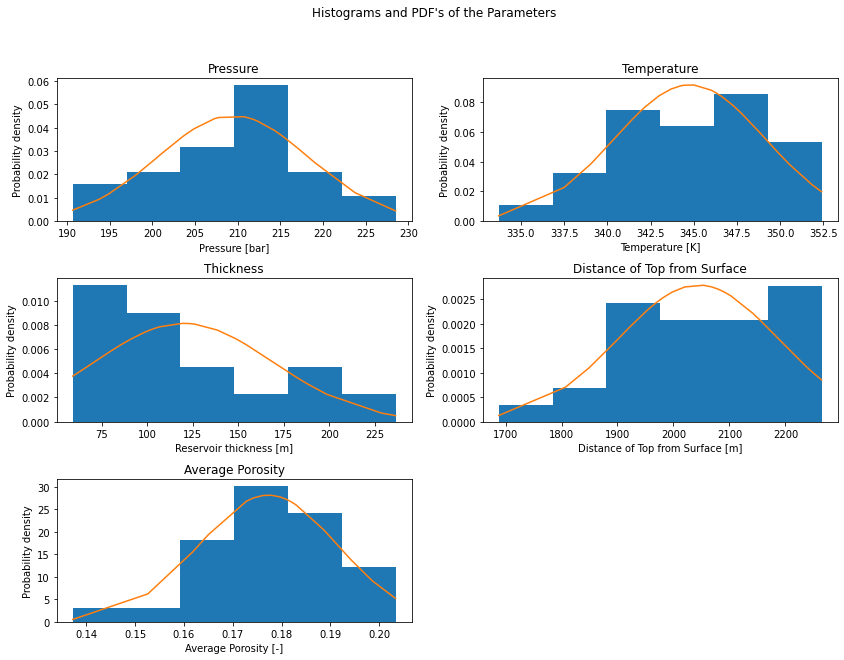

In [3]:
# Create the needed amount of suplots
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(14,10))
fig.suptitle("Histograms and PDF's of the Parameters")
ax6.set_visible(False)

# Create lists to make loop functionable
axes = [ax1, ax2, ax3, ax4, ax5]
params = data.columns
titles = ['Pressure', 'Temperature', 'Thickness', 'Distance of Top from Surface', 'Average Porosity']
x_labels = ['Pressure [bar]', 'Temperature [K]', 'Reservoir thickness [m]',
            'Distance of Top from Surface [m]', 'Average Porosity [-]']

# Loop over each parameters
for i in range(5):
    # Grab the relevant data
    ax_i = axes[i]
    data_i = data[params[i]].sort_values()
    
    # Fit the ditrubtion
    pdf = pdf_norm(data_i, data_i.mean(), data_i.std())
    
    # Plot
    ax_i.hist(data_i, bins=6, density=True)
    ax_i.plot(data_i, pdf)
    
    # Add titles, and x and y labels
    ax_i.set_title(titles[i])
    ax_i.set_xlabel(x_labels[i])
    ax_i.set_ylabel('Probability density')

fig.subplots_adjust(hspace=0.4)

Although it is tough to see what the best distribution should be for certain parameters ,since 30 entries is not really a lot of data, they all seem to best correlate with the normal (Gaussian). This is especially vague for the Thickness parameter, but if the bins of the histogram are increased the typical normal distribution becomes clearer.  

To check wether the normal distribution is an acceptable fit for the data, we can plot the normal CDF against the emperical CDF:

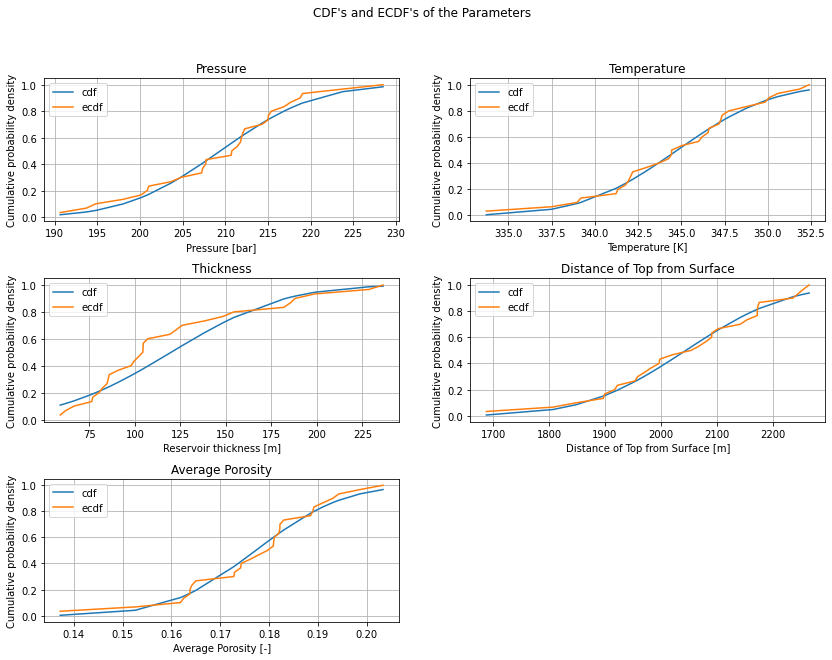

In [4]:
# Create the needed amount of suplots
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(14,10))
fig.suptitle("CDF's and ECDF's of the Parameters")
ax6.set_visible(False)

# Create lists to make loop functionable
axes = [ax1, ax2, ax3, ax4, ax5]
params = data.columns
titles = ['Pressure', 'Temperature', 'Thickness', 'Distance of Top from Surface', 'Average Porosity']
x_labels = ['Pressure [bar]', 'Temperature [K]', 'Reservoir thickness [m]',
            'Distance of Top from Surface [m]', 'Average Porosity [-]']

# Loop over each parameters
for i in range(5):
    # Grab the relevant data
    ax_i = axes[i]
    data_i = data[params[i]].sort_values()
    
    # Fit the ditrubtion
    cdf_i = cdf_norm(data_i, data_i.mean(), data_i.std())
    ecdf_i, f = ecdf(data_i)
    
    # Plot
    ax_i.plot(data_i, cdf_i, label='cdf')
    ax_i.plot(ecdf_i, f, label='ecdf')
    
    # Add titles, and x and y labels and graph-makeup
    ax_i.set_title(titles[i])
    ax_i.set_xlabel(x_labels[i])
    ax_i.set_ylabel('Cumulative probability density')
    ax_i.legend()
    ax_i.grid()

fig.subplots_adjust(hspace=0.4)

From plotting the histograms we observed that our variables are more accuratly described by normal distribution. We also tried to fit a gumbel but the results with normal distribution were more accurate. Moreover, for the reservoir depth we tried the exponential function as well but it was not describing the first largest values well. Our distribution choices were also validated empirically by plotting the CDF and ECDF plots where all variables follow each other closely.

In the future, there are also some statistical tests like "goodness of fit" that can help pick the best fitting distribution for a given parameters. These will be adressed later during MUDE.

## Check correlations

In the following code cell all pearson correlations coefficient values are calculated for all parameter combinations, and displayed in a table.

$$
ρ_(x,y) = \frac{E(X-μ_x,Y-μ_y)}{(σ_x*σ_y)}
$$


Pearson correlation coefficient (r) value  | Strength | Direction
------------- | ------------- | ------------- 
Greater than .5 | Strong | Positive
Between .3 and .5  | Moderate |Positive
Between 0 and .3|Weak|Positive
0 | None | None
Between 0 and -.3 | Weak | Negative
Between -.3 and -.5 | Moderate | Negative
Less than -.5 | Strong | Negative

In [5]:
# Calculate all the relevant correlation values
'-----------------------p-----------------------'
cor_p_T = pearsonr(data['p [bar]'],data['T [K]'])
cor_p_d = pearsonr(data['p [bar]'],data['t [m]'])
cor_p_d_top = pearsonr(data['p [bar]'],data['d_top [m]'])
cor_p_n = pearsonr(data['p [bar]'],data['n_avg [-]'])

'-----------------------T-----------------------'
cor_T_d = pearsonr(data['T [K]'],data['t [m]'])
cor_T_d_top = pearsonr(data['T [K]'],data['d_top [m]'])
cor_T_n = pearsonr(data['T [K]'],data['n_avg [-]'])


'-----------------------d-----------------------'
cor_d_d_top = pearsonr(data['t [m]'],data['d_top [m]'])
cor_d_n = pearsonr(data['t [m]'],data['n_avg [-]'])

'-----------------------d_top-----------------------'
cor_d_top_n = pearsonr(data['d_top [m]'],data['n_avg [-]'])

ind = ['p [bar]', 'T [K]', 't [m]', 'd_top [m]', 'n_avg [-]']

#Create and fill a matrix to nicely display the correlation values
A = np.array([
    ['-',  round(cor_p_T[0],4), round(cor_p_d[0],4), round(cor_p_d_top[0],4), round(cor_p_n[0],4)],
    [round(cor_p_T[0],4), '-', round(cor_T_d[0],4), round(cor_T_d_top[0],4), round(cor_T_n[0],4)],
    [round(cor_p_d[0],4), round(cor_T_d[0],4), '-', round(cor_d_d_top[0],4), round(cor_d_n[0],4)],
    [round(cor_p_d_top[0],4), round(cor_T_d_top[0],4), round(cor_d_d_top[0],4), '-', round(cor_d_top_n[0],4)],
    [round(cor_p_n[0],4), round(cor_T_n[0],4), round(cor_d_n[0],4), round(cor_d_top_n[0],4), '-'],
])

a = pd.DataFrame(A, index=ind, columns=ind)
display(a)

,p [bar],T [K],t [m],d_top [m],n_avg [-]
p [bar],-,0.8128,0.1577,0.8429,0.5136
T [K],0.8128,-,-0.0828,0.9683,0.518
t [m],0.1577,-0.0828,-,-0.0397,0.1881
d_top [m],0.8429,0.9683,-0.0397,-,0.5659
n_avg [-],0.5136,0.518,0.1881,0.5659,-


For the visualization we are only interested in the parameters that have a strong correlation. In this case we take all r-values above 0.6 and below -0.6. In the code below we will plot these variables against eachother.

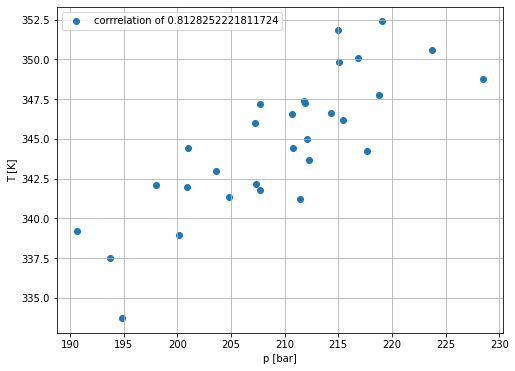

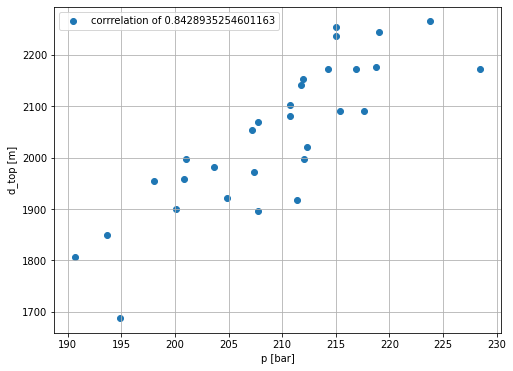

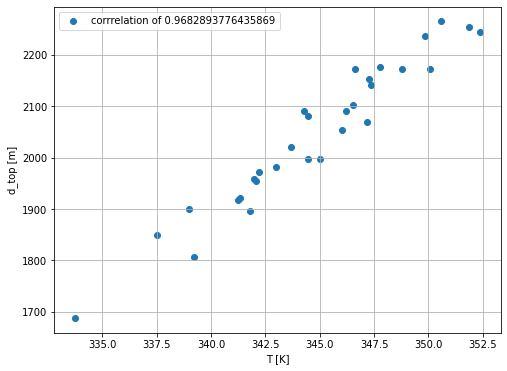

In [6]:
cor = []
for i in data.columns:
    for j in data.columns:
        r = pearsonr(data[i], data[j])[0]
        if i != j and r not in cor and (r > 0.6 or  r < -0.6):
            cor.append(pearsonr(data[i], data[j])[0])
            plt.figure(figsize=(8, 6))
            plt.scatter(data[i], data[j], label=f'corrrelation of {r}')
            plt.legend()
            plt.xlabel(i)
            plt.ylabel(j)
            plt.grid()

As reafirmed by the graphs, the strongest correlations between different parameters are:

- Temperature and Pressure

- Depth of Top from Surface and Pressure

- Depth of Top from Surface and Temperature

## Gas Compresibility

With the Pressure and Temperature at each well known, the comperssibility factor (Z) can be calculated by for the three situations outlined in the Project PDF. The situations are:
1. 95% CO2 + 5% N2
2. 95% H2 + 5% C1
3. 85% C1 + 10% C2 + 5% H2S

These situations are denoted in the DataFrame as 'Z_1', 'Z_2' and 'Z_3'.

In [7]:
# Setup all the scenarios and ratios for the loop
scenarios = [['CO2', 'N2'], ['H2', 'C1'], ['C1', 'C2', 'H2S']]
ratios = [[0.95, 0.05], [0.95, 0.05], [0.85, 0.10, 0.05]]
data = data.sort_index()

for i in range(len(scenarios)):
    z_i = []
    for j in range(len(data)):
        # Calculate the Z function for one scenario for one well
        z_ij = z_calc(data['p [bar]'][j], data['T [K]'][j], ratios[i], scenarios[i])[0]
        z_i.append(z_ij)

    data[f"Z_{i+1}"] = z_i
    
data.head()

,p [bar],T [K],t [m],d_top [m],n_avg [-],Z_1,Z_2,Z_3
0,190.657,339.194,82.15,1807.00,0.161835,0.557363,1.129878,0.820866
1,204.845,341.336,126.02,1922.14,0.189198,0.582882,1.140191,0.835770
2,198.011,342.076,107.07,1953.64,0.163787,0.572278,1.134729,0.830726
3,210.697,346.547,181.79,2102.64,0.183000,0.596989,1.143152,0.847612
4,211.411,341.225,122.67,1917.34,0.177893,0.593897,1.145307,0.842029


Multiple statisics can be gathered form these values. First of, if we only want the know the average compressibility factor for each situation:

In [8]:
print(f"Average Z for Scenario 1: {data['Z_1'].mean():.5f}")
print(f"Average Z for Scenario 2: {data['Z_2'].mean():.5f}")
print(f"Average Z for Scenario 3: {data['Z_3'].mean():.5f}")

Average Z for Scenario 1: 0.59329
Average Z for Scenario 2: 1.14268
Average Z for Scenario 3: 0.84438


If we want to look at the overall distribution of the Z for each scenario, we can create the same distribution fit as with the parameters:

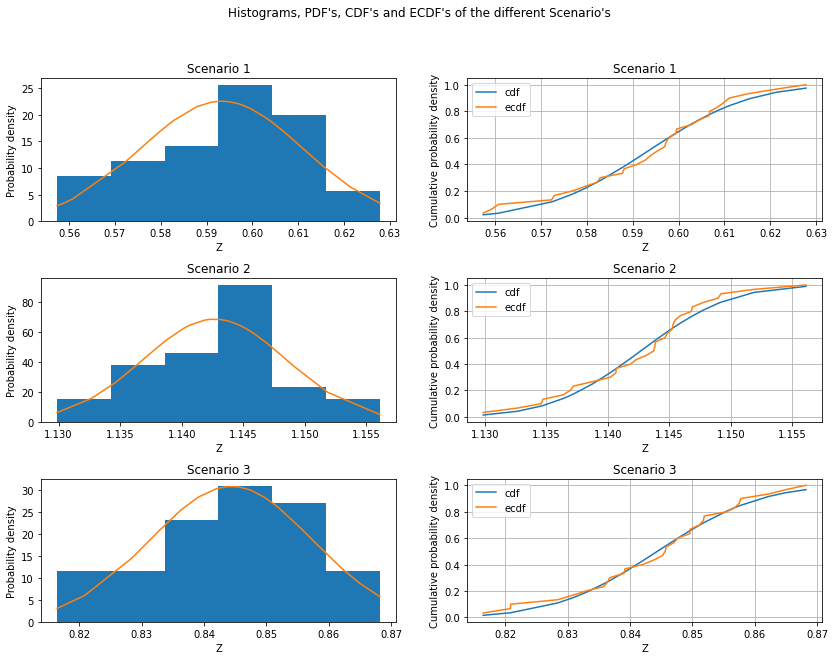

In [9]:
# Create the needed amount of suplots
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(14,10))
fig.suptitle("Histograms, PDF's, CDF's and ECDF's of the different Scenario's")

# Create lists to make loop functionable
axes = [ax1, ax2, ax3, ax4, ax5, ax6]
params = data.columns[-3:]
titles = ['Scenario 1', 'Scenario 2', 'Scenario 3']

# Loop over each parameters
for i in range(3):
    # Grab the relevant data
    data_i = data[params[i]].sort_values()
    
    # Fit the ditrubtion
    pdf = pdf_norm(data_i, data_i.mean(), data_i.std())
    cdf_i = cdf_norm(data_i, data_i.mean(), data_i.std())
    ecdf_i, f = ecdf(data_i)
    
    # Plot
    j = i * 2
    axes[j].hist(data_i, bins=6, density=True)
    axes[j].plot(data_i, pdf)
    axes[j+1].plot(data_i, cdf_i, label='cdf')
    axes[j+1].plot(ecdf_i, f, label='ecdf')
    
    # Add titles, and x and y labels and other graph-makeup
    axes[j].set_title(titles[i])
    axes[j].set_xlabel('Z')
    axes[j].set_ylabel('Probability density')
    axes[j+1].set_title(titles[i])
    axes[j+1].set_xlabel('Z')
    axes[j+1].set_ylabel('Cumulative probability density')
    axes[j+1].legend()
    axes[j+1].grid()

fig.subplots_adjust(hspace=0.4)

Again we see that the normal distribution is the best fit for all scenario's. Which is normal as they're outcomes from normally distributed parameters.

To see if there is a correlation between the temperature and pressure and Z, we create some scatterplots. As all the different scenario's observe the same behaviour for Z, we will only look at one scenario's scatterplot to determine the relation for all.

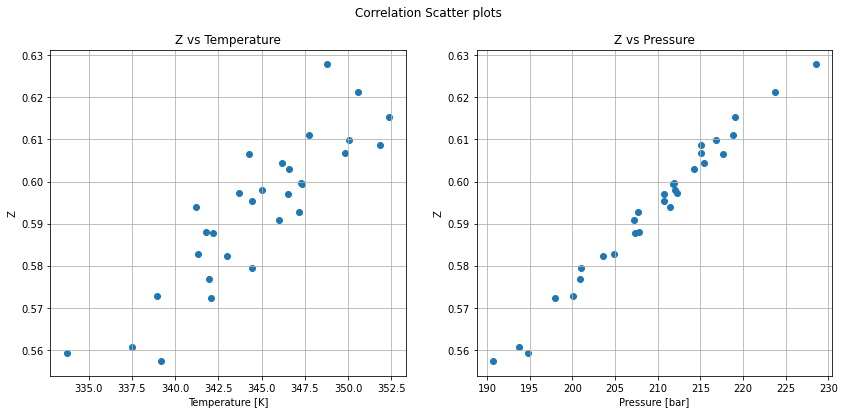

In [10]:
# Create the needed amount of suplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle("Correlation Scatter plots")

# Plot
ax1.scatter(data['T [K]'], data['Z_1'])
ax2.scatter(data['p [bar]'], data['Z_1'])

# Add graph information
ax1.set_title('Z vs Temperature')
ax2.set_title('Z vs Pressure')
ax1.set_ylabel('Z')
ax2.set_ylabel('Z')
ax1.set_xlabel('Temperature [K]')
ax2.set_xlabel('Pressure [bar]');
ax1.grid()
ax2.grid()

As is visible from the graphs, both the Temperature and Presurre have a positive correlation with Z, with the correlation with the presurre being especially significant.

Now to calculate the pressure change, the ODE will be solved numerically by using the forward Euler method

$$
y_(n+1)=y_n+dt*f(t_n,y_n)
$$

Then the subsidance that is caused from the pressure decrease will be calculated.

To calculate rho phi and dphi drho 3 assisting functions were used.


For the exercise, after 20 years the pressure = 66.566 [bar], and the subsidence = 0.107 [m]


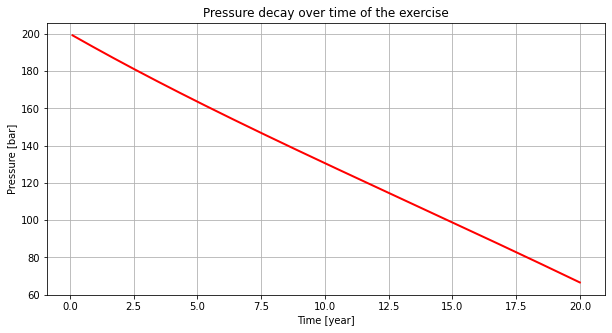

In [13]:
#This should probably be hidden as it's just a test for the functions

p_0 = 200 # [bar]
temp_sc = 288 # [K]
phi0 = 0.2 # [-]

rock_compr = 1e-5 # rock compressibilty factor [-]
comp = ['C1', 'N2', 'CO2'] # mixture components
y = [.85, .10, .05] # percentages of the mixture components

temp = temp_sc + 60 

X = 1000
Y = 1000
h = 80

volume = X*Y*h # volume of the reservoir
gas_extracted_surf = 100e6 # flux of gas extracted from the surface level [m^3*s^(-1)]

year = 0 # initial value
p_vec = []
t_vec = []
p = p_0

dt = 0.1 # timestep interval 
gas_extracted_mass = dt * gas_extracted_surf * calculate_rho_gas(1, temp_sc, comp, y) # amount of mass extracted [kg]

for year in np.arange(0, 20, dt):
    rho = calculate_rho_gas(p, temp, comp, y) # density [kg/m^3]
    pn = p + gas_extracted_mass / volume / calculate_dphi_drho(p, temp, comp, y, phi0, p_0)
    year += dt
    t_vec.append(year)
    p_vec.append(pn)
    p = pn
    
total_subsidence = (p_0 - pn) * rock_compr * h # final subsidence [m] 
print(f'For the exercise, after 20 years the pressure = {p:.3f} [bar], and the subsidence = {total_subsidence:.3f} [m]')

plt.figure(figsize=(10,5))
plt.plot(t_vec, p_vec, 'red', linewidth=2)
plt.xlabel('Time [year]')
plt.ylabel('Pressure [bar]')
plt.title('Pressure decay over time of the exercise')
plt.grid()

## Applying our functions to last week's data

With the functions to analyze the pressure changes completed, we can look at the pressure-time distribution for our own well data for a similar extraction situation. To do this we look at both average and the 95-th percentile values of the pressure, porosity, temperature and thickness. 

For the mean values, after 20 years the pressure = 107.234 [bar], and the subsidence = 0.123 [m]

For the 95-th percentile values, after 20 years the pressure = 163.764 [bar], and the subsidence = 0.125 [m]


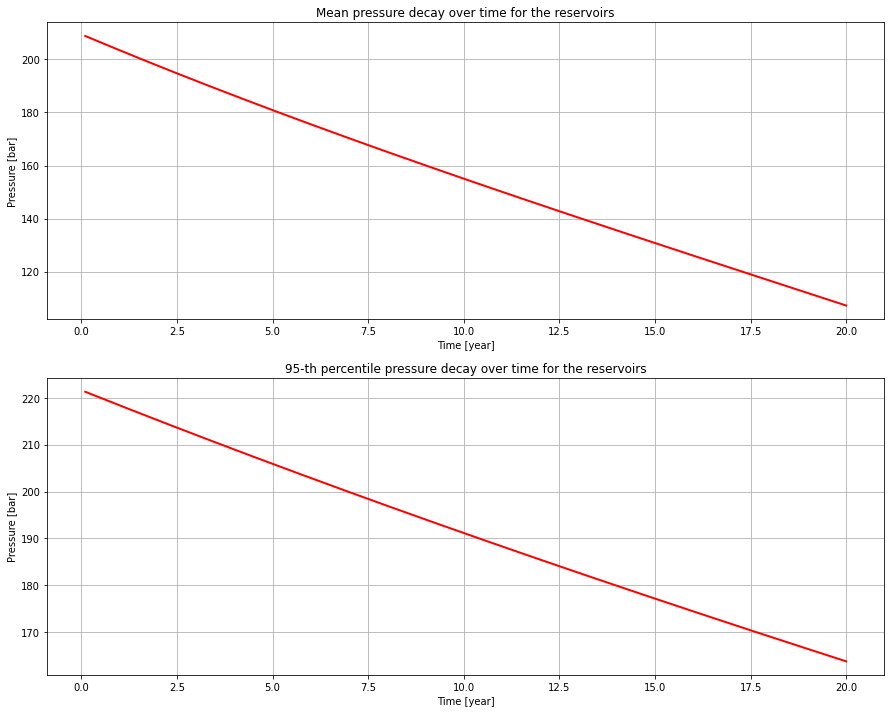

In [12]:
plt.figure(figsize=(15, 12))

# 
rock_compr = 1e-5 # rock compressibility factor [-]
gas_extracted_surf = 100e6 # flux of gas extracted from the surface level [m^3*s^(-1)]

# Mean values computations of our data
p_0 = data['p [bar]'].mean() # initial pressure [bar]
phi0 = data['n_avg [-]'].mean() # initial porosity [-]
temp = data['T [K]'].mean() # initial temperature [K]
h = data['t [m]'].mean() # initial thickness of the reservoir [m]

subsidence = 0 
rock_compr = 1e-5
comp = ['C1', 'N2', 'CO2']
y = [.85, .10, .05]

X = 1000
Y = 1000

volume = X*Y*h
gas_extracted_surf = 100e6

year = 0
p_vec = []
t_vec = []
p = p_0

dt = 0.1
gas_extracted_mass = dt * gas_extracted_surf * calculate_rho_gas(1, temp_sc, comp, y) # amount of mass extracted [kg]

for year in np.arange(0, 20, dt):
    
    rho = calculate_rho_gas(p, temp, comp, y)
    pn = p + gas_extracted_mass / volume / calculate_dphi_drho(p, temp, comp, y, phi0, p_0)
    year += dt
    t_vec.append(year)
    p_vec.append(pn)
    p = pn

subsidence = (p_0 - pn) * rock_compr * h # final subsidence [m]   
print(f'For the mean values, after 20 years the pressure = {p:.3f} [bar], and the subsidence = {subsidence:.3f} [m]\n')

plt.subplot(211)
plt.plot(t_vec, p_vec, 'red', linewidth=2)
plt.xlabel('Time [year]')
plt.ylabel('Pressure [bar]')
plt.title('Mean pressure decay over time for the reservoirs')
plt.grid()

# 95-th percentile

p_0 = data['p [bar]'].quantile(0.95)
phi0 = data['n_avg [-]'].quantile(0.95)
temp = data['T [K]'].quantile(0.95)
h = data['t [m]'].quantile(0.95)

subsidence = 0 
rock_compr = 1e-5
comp = ['C1', 'N2', 'CO2']
y = [.85, .10, .05]

X = 1000
Y = 1000

volume = X*Y*h
gas_extracted_surf = 100e6

year = 0
p_vec = []
t_vec = []
p = p_0

dt = 0.1
N = int(20 / 0.1)
gas_extracted_mass = dt * gas_extracted_surf * calculate_rho_gas(1, temp_sc, comp, y)

for i in range(N):

    rho = calculate_rho_gas(p, temp, comp, y)
    pn = p + gas_extracted_mass / volume / calculate_dphi_drho(p, temp, comp, y, phi0, p_0)
    year += dt
    t_vec.append(year)
    p_vec.append(pn)
    p = pn

subsidence += (p_0 - pn) * rock_compr * h 
print(f'For the 95-th percentile values, after 20 years the pressure = {p:.3f} [bar], and the subsidence = {subsidence:.3f} [m]')

plt.subplot(212)
plt.plot(t_vec, p_vec, 'red', linewidth=2)
plt.xlabel('Time [year]')
plt.ylabel('Pressure [bar]')
plt.title('95-th percentile pressure decay over time for the reservoirs')
plt.grid()

### Conclusion

As we can see from the graphs, there is a significant difference in the amount of pressure between the mean and the 95-th quantile values.
However, this doesn't cause a significant increase in subsidence because it mainly depends on the difference of pressure and not on the pressure itself. 

Another thing that might be worth looking into is what would happen with different pressure scenarios, as the subsidence increases with higher pressure differentials.